# 4. Inventory Management — Learning a Reorder Policy

**The business problem:** A retailer/warehouse manager reviews stock every period (day/week) and decides how much to reorder. Demand is uncertain. Order too little and you get stockouts (lost sales, unhappy customers); order too much and you pay for storage (holding cost) and tie up capital. This is the **inventory / supply chain replenishment** problem, one of the oldest and most studied problems in Operations Research — and a great second business case because it introduces something new: **the agent's own action changes the state directly** (ordering more inventory literally changes how much inventory there is), not just how fast a fixed pool depletes like in dynamic pricing.

State/action/reward mapping, same MDP skeleton as before:

| Notebook 3 (pricing) | This notebook (inventory) |
|---|---|
| State = (units left, days left) | State = **inventory on hand** |
| Action = which price to charge | Action = **how much to reorder** |
| Reward = price if sold | Reward = **revenue − ordering cost − holding cost − stockout penalty** |
| Capacity only ever decreases | Inventory can go **up** (ordering) or down (sales) |

The classical Operations Research answer to this problem is an **(s, S) policy**: *"if inventory drops below a reorder point `s`, order enough to bring it back up to a target level `S`; otherwise order nothing."* It's a strong, well-understood baseline — so a fair test for RL here isn't "does it beat doing nothing," it's **"can a learned policy match or beat a well-tuned classical heuristic that decades of operations research have refined?"**

In [15]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)
plt.rcParams['figure.figsize'] = (9, 4.5)

## Step 1 — Simulate the environment

Each period: the agent sees current inventory, places an order (arrives immediately, a simplifying assumption — real systems have lead times, which we mention again at the end), demand is drawn at random, sales are fulfilled up to available stock, and any demand beyond that is a lost sale.

In [16]:
MAX_INVENTORY = 50            # warehouse capacity
ORDER_OPTIONS = [0, 10, 20, 30, 40]   # discrete order-quantity choices

UNIT_PRICE = 10.0              # revenue per unit sold
UNIT_COST = 4.0                # cost per unit ordered
FIXED_ORDER_COST = 5.0         # fixed cost incurred any time an order is placed (e.g. shipping/admin)
HOLDING_COST = 0.5             # cost per unit held in stock at period end
STOCKOUT_COST = 8.0            # penalty per unit of unmet demand (lost margin + goodwill)
DEMAND_MEAN = 15               # average units demanded per period
EPISODE_LENGTH = 200           # periods per simulated horizon (e.g. ~200 trading days)

def step(inventory, order_qty):
    # in one step we assume that the agent places an order of order_qty units which arrives immediately, 
    # and then demand occurs. The agent receives a reward based on the revenue from sales, minus costs 
    # for ordering, holding inventory, and lost sales.

    capacity = MAX_INVENTORY - inventory # available capacity in warehouse
    real_order_qty = min(order_qty, capacity)  # can't exceed capacity, this means the real order quantity may be less than the requested order quantity
    stock_after_order = inventory + real_order_qty
    demand = rng.poisson(DEMAND_MEAN)
    sold = min(demand, stock_after_order) # we cannnot sell more than we have in stock
    lost_sales = max(0, demand - stock_after_order) # if demand exceeds stock, we have lost sales (penalty)
    next_inventory = stock_after_order - sold

    revenue = UNIT_PRICE * sold
    ordering_cost = UNIT_COST * real_order_qty + (FIXED_ORDER_COST if real_order_qty > 0 else 0.0)
    holding_cost = HOLDING_COST * next_inventory # the cost of holding the inventory regardless of whether it is sold or not
    stockout_penalty = STOCKOUT_COST * lost_sales # the penalty for not meeting demand
    reward = revenue - ordering_cost - holding_cost - stockout_penalty

    return next_inventory, reward

## Step 2 — The classical baseline: an (s, S) policy
Let's create a reference to beat with our RL model. So we will implement a very simple policy that doesn't include any type of ML technique.


Let's implement the industry-standard heuristic and tune its two parameters (`s`, the reorder point, and `S`, the order-up-to level) by simply trying a few combinations — exactly what an operations analyst would do.

In [17]:
# the (s, S) policy is a simple inventory control policy where s and S are static parameters.
# - if the inventory level falls below a threshold s, we order enough to bring it up to S
# - if the inventory level is above s, we do not order anything

# the "step" function simulates one period of the inventory management process, 
# given the current inventory level and the order quantity. 
# it can be used either for simulating the (s, S) policy or for training a reinforcement learning agent.
def run_sS_policy(s, S, T=EPISODE_LENGTH, start_inventory=20):
    inventory = start_inventory
    total_reward = 0.0
    for t in range(T):
        order_qty = max(0, S - inventory) if inventory < s else 0
        inventory, reward = step(inventory, order_qty)
        total_reward += reward
    return total_reward

candidates = [(10, 30), (10, 40), (15, 45), (20, 45), (5, 35)]
print(f"{'(s, S)':<12}{'Avg total reward / 200 periods':>32}")
for s, S in candidates:
    revs = [run_sS_policy(s, S) for _ in range(500)]
    print(f"({s}, {S}){'':<5}{np.mean(revs):>32.1f}")

(s, S)        Avg total reward / 200 periods
(10, 30)                              14226.9
(10, 40)                              14583.4
(15, 45)                              15375.4
(20, 45)                              15375.0
(5, 35)                              12121.8


We'll carry the best of these forward as **the baseline to beat** — this mirrors how you'd defend an RL business case in practice: not against a strawman, but against the best conventional policy you could reasonably deploy.

## Step 3 — Q-learning reorder policy

State = inventory level (an integer from 0 to 50). Action = index into `ORDER_OPTIONS`. Same Q-learning update as the previous two notebooks.

In [18]:
GAMMA = 0.95
N_EPISODES = 20_000

# we initialize the Q-table with zeros, where rows represent inventory levels and columns represent order options
Q = np.zeros((MAX_INVENTORY + 1, len(ORDER_OPTIONS)))
 # VISITS to keep track of how many times each state-action pair has been visited, for learning rate calculation
VISITS = np.zeros((MAX_INVENTORY + 1, len(ORDER_OPTIONS)))

def epsilon_schedule(episode):
    # we will start with a high exploration rate and gradually reduce it over time, but never below 0.05
    return max(0.05, 1.0 - episode / (N_EPISODES * 0.5))

def run_rl_episode(train=True, epsilon=0.0, start_inventory=20, T=EPISODE_LENGTH):
    inventory = start_inventory
    total_reward = 0.0
    for t in range(T):
        if train and rng.random() < epsilon:
            action = rng.integers(len(ORDER_OPTIONS)) # exploration 
        else:
            action = int(np.argmax(Q[inventory])) # exploitation (if train is False, we always exploit)
        order_qty = ORDER_OPTIONS[action]

        next_inventory, reward = step(inventory, order_qty)
        total_reward += reward

        if train:
            best_next = np.max(Q[next_inventory])
            td_target = reward + GAMMA * best_next
            VISITS[inventory, action] += 1
            alpha = 1.0 / VISITS[inventory, action]
            Q[inventory, action] += alpha * (td_target - Q[inventory, action])

        inventory = next_inventory
    return total_reward

training_rewards = []
for ep in range(N_EPISODES):
    training_rewards.append(run_rl_episode(train=True, epsilon=epsilon_schedule(ep)))

print(f"Avg reward/episode, first 500: {np.mean(training_rewards[:500]):.1f}")
print(f"Avg reward/episode, last 500:  {np.mean(training_rewards[-500:]):.1f}")

Avg reward/episode, first 500: 13281.2
Avg reward/episode, last 500:  15588.7


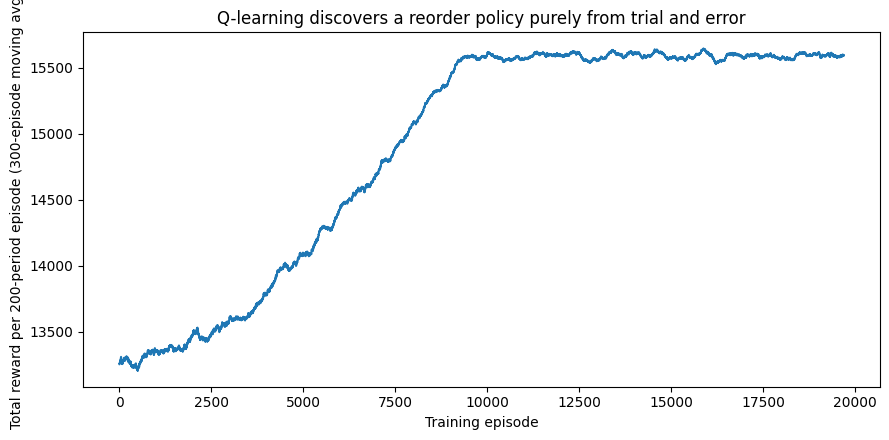

In [19]:
smoothed = np.convolve(training_rewards, np.ones(300)/300, mode="valid")
plt.figure()
plt.plot(smoothed)
plt.xlabel("Training episode")
plt.ylabel(f"Total reward per {EPISODE_LENGTH}-period episode (300-episode moving avg)")
plt.title("Q-learning discovers a reorder policy purely from trial and error")
plt.tight_layout()
plt.show()

## Step 4 — RL vs. the best (s, S) policy, head-to-head

Policy                       Avg reward     Std dev
(s,S) = (15, 45)                15384.0       330.4
Learned RL policy               15780.7       312.1


C:\Users\Pablo\AppData\Local\Temp\ipykernel_30048\2502434248.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sS_revenues, rl_revenues], labels=["(s,S) = (15, 45)", "Learned RL policy"], showmeans=True)


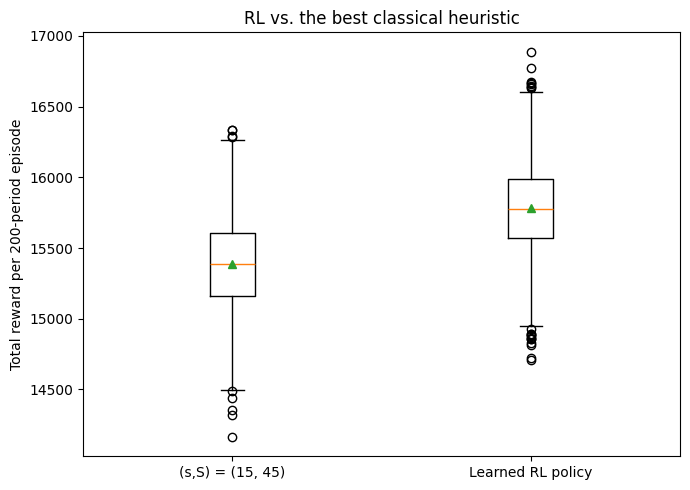

In [20]:
best_s, best_S = 15, 45  # the strongest candidate from Step 2
N_EVAL = 2000

sS_revenues = [run_sS_policy(best_s, best_S) for _ in range(N_EVAL)]
rl_revenues = [run_rl_episode(train=False, epsilon=0.0) for _ in range(N_EVAL)]

print(f"{'Policy':<25}{'Avg reward':>14}{'Std dev':>12}")
print(f"{'(s,S) = (15, 45)':<25}{np.mean(sS_revenues):>14.1f}{np.std(sS_revenues):>12.1f}")
print(f"{'Learned RL policy':<25}{np.mean(rl_revenues):>14.1f}{np.std(rl_revenues):>12.1f}")

plt.figure(figsize=(7, 5))
plt.boxplot([sS_revenues, rl_revenues], labels=["(s,S) = (15, 45)", "Learned RL policy"], showmeans=True)
plt.ylabel(f"Total reward per {EPISODE_LENGTH}-period episode")
plt.title("RL vs. the best classical heuristic")
plt.tight_layout()
plt.show()

Don't expect RL to blow the (s, S) policy out of the water — (s, S) policies are provably optimal or near-optimal for many classical inventory problems, which is exactly why they're the industry standard. What you should see is the RL policy **matching or slightly edging out** a well-tuned (s, S) baseline, *without anyone telling it the shape of an (s, S) policy* — it discovered a comparably good strategy purely from reward feedback. In a consulting context, that's the pitch for RL here: not "replaces operations research," but "can automatically find (and adapt) a policy at least as good as your best heuristic, including for messier variants of the problem where a clean (s, S) formula doesn't exist" (e.g. multiple products competing for shared warehouse space, correlated demand, non-stationary seasonality).

## Step 5 — What policy did it actually learn?

Since the state here is a single number (inventory level), we can plot the whole policy as a simple curve: order quantity vs. current inventory.

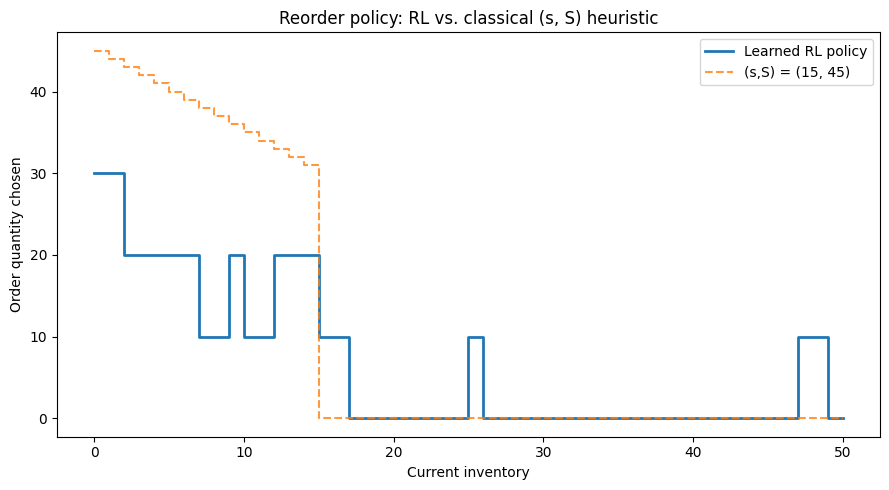

In [21]:
inventories = np.arange(0, MAX_INVENTORY + 1)
learned_orders = [ORDER_OPTIONS[int(np.argmax(Q[i]))] for i in inventories]
sS_orders = [max(0, best_S - i) if i < best_s else 0 for i in inventories]

plt.figure(figsize=(9, 5))
plt.step(inventories, learned_orders, where="post", label="Learned RL policy", linewidth=2)
plt.step(inventories, sS_orders, where="post", label=f"(s,S) = ({best_s}, {best_S})", linestyle="--", alpha=0.8)
plt.xlabel("Current inventory")
plt.ylabel("Order quantity chosen")
plt.title("Reorder policy: RL vs. classical (s, S) heuristic")
plt.legend()
plt.tight_layout()
plt.show()

If training went well, the RL curve should look a lot like a (possibly noisier, less crisp) version of the (s, S) staircase: order a lot when inventory is low, and order nothing once inventory is comfortably high. That's a reassuring sign — it means RL **rediscovered** a sensible, well-known inventory strategy from scratch, rather than finding some inscrutable policy that merely scores well in simulation. Any inventory levels that are rarely visited during training (e.g. very high stock, if the policy quickly learns to avoid over-ordering) may show noisier, less trustworthy choices — the same coverage limitation we saw in the pricing notebook.

## Key takeaways

1. Inventory management is an MDP where **the action changes the state directly** (ordering adds to inventory) — richer than pricing's "state only depletes."
2. The fair benchmark for a business RL pitch isn't "no policy" — it's **the best classical/heuristic policy already in use**. Here that's the (s, S) policy from Operations Research.
3. A good outcome isn't necessarily "RL wins by a mile" — it's **RL matches or edges out a strong, well-tuned baseline without being told the answer's shape**, which builds confidence it will also handle messier variants where no clean formula exists.
4. Plotting the learned policy against the classical one is a powerful sanity check: if RL "rediscovers" the (s, S) shape, you can trust it; if it looks nothing like a sensible policy, that's a red flag before deployment, not after.

Next: **marketing / offer targeting**, where we bring back the bandit framing from notebook 1, but add customer **context** (features) — a *contextual bandit* — which is one of the most widely deployed RL-adjacent techniques in industry (ad targeting, personalized offers, content ranking).